# Import des bibliothèques

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, length, when, lower, regexp_replace
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF
from pyspark.ml import Pipeline
import time
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, NaiveBayes
from pyspark.ml.feature import StringIndexer
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix
import subprocess
from pymongo import MongoClient
from datetime import datetime

# Connexion à Spark

In [3]:


spark = SparkSession.builder \
    .appName("YelpSentimentAnalysis") \
    .master("local[2]") \
    .config("spark.driver.memory", "2g") \
    .config("spark.executor.memory", "2g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .getOrCreate()

print(f"✅ SparkSession démarrée")
print(f"   Version Spark : {spark.version}")
print(f"   Master        : {spark.sparkContext.master}")
print(f"   App Name      : {spark.sparkContext.appName}")

✅ SparkSession démarrée
   Version Spark : 3.5.0
   Master        : local[2]
   App Name      : YelpSentimentAnalysis


# Lecture HDFS

In [4]:


# ── Chargement depuis HDFS /data/yelp/raw/ ───────────────────────
HDFS_RAW = "hdfs://namenode:9000/data/yelp/raw/yelp_academic_dataset_review.json"

print("📂 Lecture du dataset depuis HDFS...")
df_raw = spark.read.json(HDFS_RAW)

print(f"✅ Dataset chargé")
print(f"   Colonnes : {df_raw.columns}")
print(f"   Total reviews : {df_raw.count():,}")

📂 Lecture du dataset depuis HDFS...
✅ Dataset chargé
   Colonnes : ['_corrupt_record', 'business_id', 'cool', 'date', 'funny', 'review_id', 'stars', 'text', 'useful', 'user_id']
   Total reviews : 4,517,287


# Nettoyage et préparation des données textuelles

In [6]:
# ── Sélection des colonnes utiles + nettoyage ────────────────────
df_clean = df_raw \
    .filter(col("_corrupt_record").isNull()) \
    .select("review_id", "user_id", "business_id", "stars", "text", "date") \
    .dropna(subset=["stars", "text"]) \
    .filter(length(col("text")) > 10) \
    .limit(250000)  # Subset EDA : 250 000 reviews

# ── Nettoyage du texte brut ──────────────────────────────────────
df_clean = df_clean.withColumn("text", lower(col("text")))
df_clean = df_clean.withColumn("text", regexp_replace(col("text"), r"http\S+|www\S+", ""))
df_clean = df_clean.withColumn("text", regexp_replace(col("text"), r"[^a-zA-Z\s]", ""))
df_clean = df_clean.withColumn("text", regexp_replace(col("text"), r"\s+", " "))

# ── Encodage variable cible ──────────────────────────────────────
# 1-2★ → negative | 3★ → neutral | 4-5★ → positive
df_labeled = df_clean.withColumn("sentiment",
    when(col("stars") <= 2, "negative")
    .when(col("stars") == 3, "neutral")
    .otherwise("positive")
)

print(f"✅ Dataset nettoyé et labelisé")
print(f"\n📊 Distribution des sentiments :")
df_labeled.groupBy("sentiment").count().orderBy("sentiment").show()

✅ Dataset nettoyé et labelisé

📊 Distribution des sentiments :
+---------+------+
|sentiment| count|
+---------+------+
| negative| 47539|
|  neutral| 28470|
| positive|173991|
+---------+------+



In [7]:

# ── Étape 3 : Tokenisation ───────────────────────────────────────
tokenizer = Tokenizer(inputCol="text", outputCol="words")

# ── Étape 4 : Suppression stopwords ─────────────────────────────
remover = StopWordsRemover(inputCol="words", outputCol="filtered")

# ── Étape 5 : Vectorisation TF-IDF ──────────────────────────────
hashingTF = HashingTF(inputCol="filtered", outputCol="rawFeatures", numFeatures=10000)
idf       = IDF(inputCol="rawFeatures", outputCol="features")

# ── Pipeline NLP complet ─────────────────────────────────────────
nlp_pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf])

print("⏳ Entraînement du pipeline NLP (TF-IDF)...")
nlp_model   = nlp_pipeline.fit(df_labeled)
df_features = nlp_model.transform(df_labeled)

print("✅ Pipeline NLP terminé !")
print("\n📋 Schéma après preprocessing :")
df_features.select("review_id", "stars", "sentiment", "features").printSchema()

⏳ Entraînement du pipeline NLP (TF-IDF)...
✅ Pipeline NLP terminé !

📋 Schéma après preprocessing :
root
 |-- review_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- sentiment: string (nullable = false)
 |-- features: vector (nullable = true)



In [8]:
HDFS_PROCESSED = "hdfs://namenode:9000/data/yelp/processed/"

print(f"💾 Sauvegarde dans HDFS : {HDFS_PROCESSED}")

df_features.select("review_id", "user_id", "business_id", "stars", "sentiment", "features", "date") \
           .write.mode("overwrite") \
           .parquet(HDFS_PROCESSED)

print("✅ Données sauvegardées dans HDFS !")

# ── Vérification ─────────────────────────────────────────────────
import subprocess
result = subprocess.run(
    ["hdfs", "dfs", "-ls", "/data/yelp/processed/"],
    capture_output=True, text=True
)
print(f"\n📂 Contenu HDFS /data/yelp/processed/ :")
print(result.stdout)

💾 Sauvegarde dans HDFS : hdfs://namenode:9000/data/yelp/processed/
✅ Données sauvegardées dans HDFS !


FileNotFoundError: [Errno 2] No such file or directory: 'hdfs'

In [9]:
# Vérification via Spark (pas subprocess)
print("📂 Contenu HDFS /data/yelp/processed/ :")
processed_df = spark.read.parquet("hdfs://namenode:9000/data/yelp/processed/")
print(f"✅ Fichier Parquet lisible !")
print(f"   Nombre de lignes : {processed_df.count():,}")
processed_df.printSchema()

📂 Contenu HDFS /data/yelp/processed/ :
✅ Fichier Parquet lisible !
   Nombre de lignes : 250,000
root
 |-- review_id: string (nullable = true)
 |-- user_id: string (nullable = true)
 |-- business_id: string (nullable = true)
 |-- stars: double (nullable = true)
 |-- sentiment: string (nullable = true)
 |-- features: vector (nullable = true)
 |-- date: string (nullable = true)



# Entraînement des 3 modèles ML Prédictions + évaluation

In [10]:


# ── Lecture depuis HDFS /data/yelp/processed/ ────────────────────
df = spark.read.parquet("hdfs://namenode:9000/data/yelp/processed/")

# ── Encodage sentiment → label numérique ─────────────────────────
indexer = StringIndexer(inputCol="sentiment", outputCol="label")
df      = indexer.fit(df).transform(df)

# ── Split 80% train / 20% test ───────────────────────────────────
train, test = df.randomSplit([0.8, 0.2], seed=42)
train_count = train.count()
test_count  = test.count()
print(f"✅ Split — Train: {train_count:,} | Test: {test_count:,}")

# ── 3 modèles (cf. section 4.3 du rapport) ───────────────────────
models = {
    "Logistic Regression": LogisticRegression(
        featuresCol="features", labelCol="label",
        maxIter=20, family="multinomial"
    ),
    "Random Forest": RandomForestClassifier(
        featuresCol="features", labelCol="label",
        numTrees=50, maxDepth=10
    ),
    "Naive Bayes": NaiveBayes(
        featuresCol="features", labelCol="label",
        smoothing=1.0
    )
}

# ── Évaluateurs ──────────────────────────────────────────────────
eval_f1        = MulticlassClassificationEvaluator(labelCol="label", metricName="f1")
eval_acc       = MulticlassClassificationEvaluator(labelCol="label", metricName="accuracy")
eval_precision = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedPrecision")
eval_recall    = MulticlassClassificationEvaluator(labelCol="label", metricName="weightedRecall")

# ── Entraînement ─────────────────────────────────────────────────
results       = {}
fitted_models = {}
predictions   = {}

for name, clf in models.items():
    print(f"\n⏳ Entraînement : {name}...")
    t0     = time.time()
    fitted = clf.fit(train)
    preds  = fitted.transform(test)
    elapsed = time.time() - t0

    f1        = eval_f1.evaluate(preds)
    acc       = eval_acc.evaluate(preds)
    precision = eval_precision.evaluate(preds)
    recall    = eval_recall.evaluate(preds)

    results[name]       = {"F1": round(f1,4), "Accuracy": round(acc,4),
                           "Precision": round(precision,4), "Recall": round(recall,4),
                           "Time": round(elapsed,1)}
    fitted_models[name] = fitted
    predictions[name]   = preds
    print(f"   ✅ F1={f1:.4f} | Accuracy={acc:.4f} | Temps={elapsed:.1f}s")

# ── Tableau récapitulatif ─────────────────────────────────────────
print("\n" + "="*70)
print(f"{'Modèle':<25} {'F1':>8} {'Accuracy':>10} {'Precision':>11} {'Recall':>8} {'Temps':>7}")
print("="*70)
for name, m in results.items():
    print(f"{name:<25} {m['F1']:>8} {m['Accuracy']:>10} {m['Precision']:>11} {m['Recall']:>8} {m['Time']:>6}s")
print("="*70)
best = max(results, key=lambda x: results[x]["F1"])
print(f"\n🏆 Meilleur modèle : {best} → F1={results[best]['F1']}")

✅ Split — Train: 199,815 | Test: 50,185

⏳ Entraînement : Logistic Regression...
   ✅ F1=0.8217 | Accuracy=0.8321 | Temps=36.6s

⏳ Entraînement : Random Forest...
   ✅ F1=0.5854 | Accuracy=0.7025 | Temps=673.6s

⏳ Entraînement : Naive Bayes...
   ✅ F1=0.7733 | Accuracy=0.7494 | Temps=5.4s

Modèle                          F1   Accuracy   Precision   Recall   Temps
Logistic Regression         0.8217     0.8321      0.8151   0.8321   36.6s
Random Forest               0.5854     0.7025      0.6667   0.7025  673.6s
Naive Bayes                 0.7733     0.7494      0.8151   0.7494    5.4s

🏆 Meilleur modèle : Logistic Regression → F1=0.8217


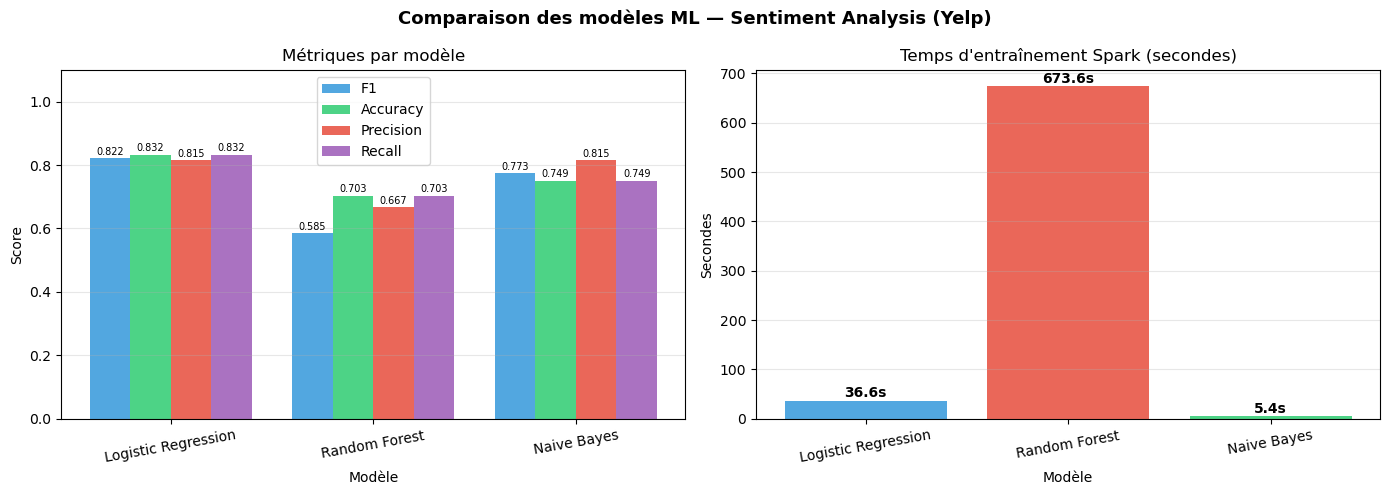

✅ Graphiques générés


In [11]:

model_names = list(results.keys())
metrics     = ["F1", "Accuracy", "Precision", "Recall"]
colors_bar  = ["#3498DB", "#2ECC71", "#E74C3C", "#9B59B6"]

x     = np.arange(len(model_names))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Comparaison des modèles ML — Sentiment Analysis (Yelp)",
             fontsize=13, fontweight="bold")

# ── Graphique 1 : Métriques ───────────────────────────────────────
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    vals = [results[m][metric] for m in model_names]
    bars = axes[0].bar(x + i*width, vals, width, label=metric, color=color, alpha=0.85)
    for bar, val in zip(bars, vals):
        axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f"{val:.3f}", ha="center", va="bottom", fontsize=7)

axes[0].set_xlabel("Modèle")
axes[0].set_ylabel("Score")
axes[0].set_title("Métriques par modèle")
axes[0].set_xticks(x + width * 1.5)
axes[0].set_xticklabels(model_names, rotation=10)
axes[0].set_ylim(0, 1.1)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.3)

# ── Graphique 2 : Temps d'entraînement ───────────────────────────
times = [results[m]["Time"] for m in model_names]
bars2 = axes[1].bar(model_names, times, color=["#3498DB", "#E74C3C", "#2ECC71"], alpha=0.85)
axes[1].set_title("Temps d'entraînement Spark (secondes)")
axes[1].set_xlabel("Modèle")
axes[1].set_ylabel("Secondes")
axes[1].tick_params(axis='x', rotation=10)
axes[1].grid(axis="y", alpha=0.3)
for bar, t in zip(bars2, times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f"{t}s", ha="center", va="bottom", fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()
print("✅ Graphiques générés")

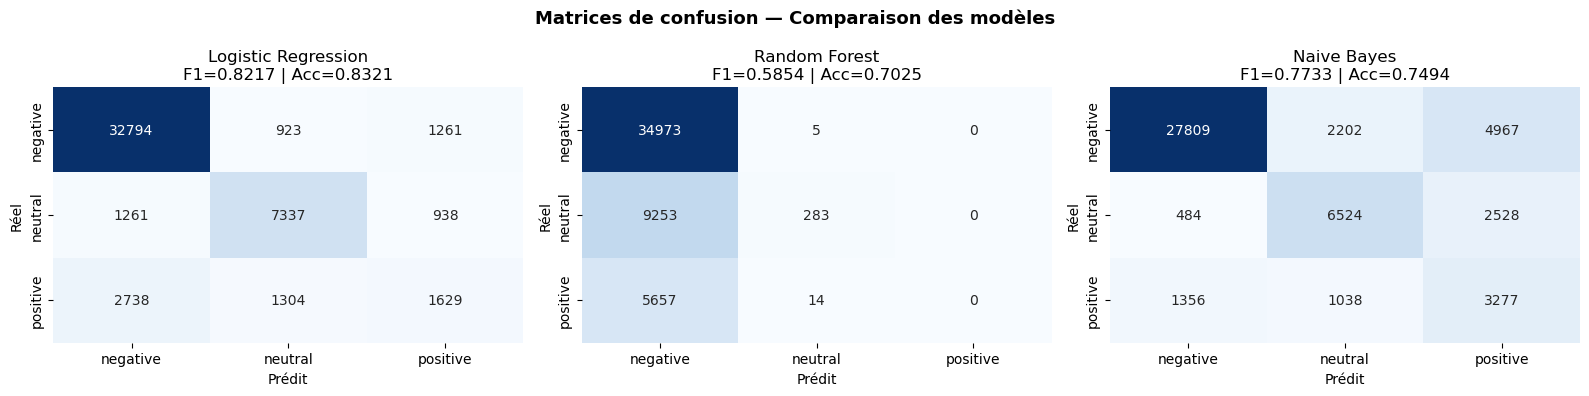

✅ Matrices de confusion générées


In [12]:


class_labels = ["negative", "neutral", "positive"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Matrices de confusion — Comparaison des modèles", fontsize=13, fontweight="bold")

for ax, (name, preds_df) in zip(axes, predictions.items()):
    pred_data = preds_df.select("label", "prediction").collect()
    y_true    = [int(row["label"])      for row in pred_data]
    y_pred    = [int(row["prediction"]) for row in pred_data]

    unique_classes = sorted(set(y_true + y_pred))
    class_names    = [class_labels[i] for i in unique_classes]

    cm = confusion_matrix(y_true, y_pred, labels=unique_classes)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, cbar=False)
    ax.set_title(f"{name}\nF1={results[name]['F1']} | Acc={results[name]['Accuracy']}")
    ax.set_xlabel("Prédit")
    ax.set_ylabel("Réel")

plt.tight_layout()
plt.show()
print("✅ Matrices de confusion générées")

In [14]:

result = subprocess.run(["pip", "install", "pymongo"], capture_output=True, text=True)
print(result.stdout)
print("✅ pymongo installé !")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/1.5 MB ? eta -:--:--
   ━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/1.5 MB 927.6 kB/s eta 0:00:02
   ━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.1/1.5 MB 1.1 MB/s eta 0:00:02
   ━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.2/1.5 MB 1.5 MB/s eta 0:00:01
   ━━━━━━━━╸━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.3/1.5 MB 1.8 MB/s eta 0:00:01
   ━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.4/1.5 MB 1.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━╺━━━━━━━━━━━━━━━━━━━━━━━━ 0.6/1.5 MB 2.2 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━ 0.8/1.5 MB 2.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━━━ 0.9/1.5 MB 2.8 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━━━━━━━ 1.0/1.5 MB 2.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━━━ 1.1/1.5 MB 2.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╸━━━━━━━ 1.2/1.5 MB 2.7 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━

# Sauvegarde dans MongoDB via pymongo

In [15]:


# ── Installation pymongo ──────────────────────────────────────────
import subprocess
subprocess.run(["pip", "install", "pymongo", "-q"], capture_output=True)

# ── Connexion MongoDB ─────────────────────────────────────────────
client = MongoClient("172.20.0.7", 27017)
db     = client["yelp_sentiment"]

# ── Collection 1 : reviews_predictions ───────────────────────────
col_predictions = db["reviews_predictions"]
col_predictions.drop()

best_preds = predictions["Logistic Regression"]
sample_rows = best_preds.select(
    "review_id", "business_id", "user_id", "stars",
    "sentiment", "prediction", "probability", "date"
).limit(5000).collect()

label_map = {0: "negative", 1: "neutral", 2: "positive"}

docs = []
for row in sample_rows:
    pred_class = int(row["prediction"])
    proba      = [float(x) for x in row["probability"]]
    docs.append({
        "review_id"       : row["review_id"],
        "business_id"     : row["business_id"],
        "user_id"         : row["user_id"],
        "stars"           : int(row["stars"]),
        "sentiment_label" : label_map.get(pred_class, "unknown"),
        "predicted_class" : pred_class,
        "probability"     : proba,
        "date"            : row["date"],
        "model_used"      : "Logistic Regression",
        "processed_at"    : datetime.now()
    })

col_predictions.insert_many(docs)
print(f"✅ {len(docs):,} prédictions sauvegardées dans MongoDB")

# ── Collection 2 : model_metrics ─────────────────────────────────
col_metrics = db["model_metrics"]
col_metrics.drop()

for name, m in results.items():
    col_metrics.insert_one({
        "model_name"    : name,
        "f1_score"      : m["F1"],
        "accuracy"      : m["Accuracy"],
        "precision"     : m["Precision"],
        "recall"        : m["Recall"],
        "train_size"    : train_count,
        "test_size"     : test_count,
        "training_time" : m["Time"],
        "trained_at"    : datetime.now()
    })
    print(f"   ✅ Métriques [{name}] sauvegardées")

# ── Vérification ──────────────────────────────────────────────────
print(f"\n📋 Vérification MongoDB :")
print(f"   reviews_predictions : {col_predictions.count_documents({}):,} documents")
print(f"   model_metrics       : {col_metrics.count_documents({})} documents")

print("\n📊 Métriques stockées :")
for doc in col_metrics.find({}, {"_id": 0, "model_name": 1, "f1_score": 1, "accuracy": 1}):
    print(f"   {doc['model_name']:<25} F1={doc['f1_score']} | Acc={doc['accuracy']}")

client.close()
print("\n✅ Connexion MongoDB fermée")

✅ 5,000 prédictions sauvegardées dans MongoDB
   ✅ Métriques [Logistic Regression] sauvegardées
   ✅ Métriques [Random Forest] sauvegardées
   ✅ Métriques [Naive Bayes] sauvegardées

📋 Vérification MongoDB :
   reviews_predictions : 5,000 documents
   model_metrics       : 3 documents

📊 Métriques stockées :
   Logistic Regression       F1=0.8217 | Acc=0.8321
   Random Forest             F1=0.5854 | Acc=0.7025
   Naive Bayes               F1=0.7733 | Acc=0.7494

✅ Connexion MongoDB fermée
